# **REDES SEQUENCE-TO-SEQUENCE** 

No material sobre autocompletar textos com *LSTM*, foi comentado sobre as diferentes sequências de *input/output* de uma rede, especialmente, a *many-to-many*, usada nesse material. Um importante problema de predição de sequência é a tradução de texto de uma língua natural para outra. Nesse caso, a sequência de *input* é uma frase no idioma de origem e a sequência de saída prevista é a frase correspondente no idioma de destino. Não é obrigatório que as duas frases tenham o mesmo número de palavras nos dois idiomas diferentes. Outra coisa importante é que a rede consuma toda a sequência de *input* antes de começar a emitir a sequência de *output*, porque, em muitos casos, é preciso considerar o significado completo de um frase para produzir uma boa tradução. Uma abordagem comum para isso é ensinar a rede a interpretar e emitir *tokens* de **START** e **STOP**, bem como valores de preenchimento (*padding*). Tanto o valor de preenchimento quanto os tokens de **START** e **STOP** devem ser valores que não aparecem naturalmente no texto. Por exemplo, com palavras representadas por índices que são entradas para uma camada de *embedding*, simplesmente reservaríamos índices específicos para esses *tokens*.

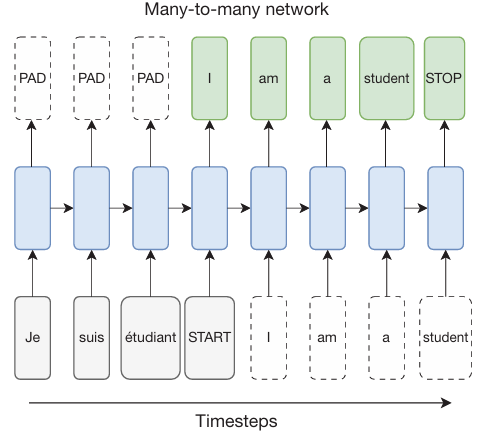 *Rede neural para tradução (many-to-many)*

A figura acima representra uma rede *many-to-many*, no qual o cinza representa o *input*, o azul é a rede e o verde é o *output*. A rede está desenrolada no tempo da esquerda para direita. A figura mostra que o comportamento desejado é que, durante os primeiros quatro passos de tempo, apresentemos os símbolos para *Je*, *suis*, *étudiant*, *START* à rede. No passo de tempo que a rede receber o token de *START*, ela produzirá a primeira palavra (*I*) da frase traduzida, seguida por *am*, *a*, *student* e *STOP*. Como sabemos, é impossível que a rede não produza um valor em uma passo de tempo, e, do mesmo jeito, a rede sempre receberá algum tipo de entrada. Isso é visto pelas formas brancas listradas a imagem. Uma solução simples para resolver isso seria usar o valor de preenchimento tanto na saída quanto na entrada para esses passos de tempo. No entanto, acontece que uma solução melhor é ajudar a rede alimentando a saída do passo de tempo anterior de volta como entrada para o próximo passo, assim como foi feito nos modelos de linguagem neurais nos materiais passados.

Ou seja, durante o treinamento, a rede verá tanto a sequência de origem quanto a de destino em sua entrada e será treinada para prever a sequência de destino em sua saída. Prever a sequência de destino como saída pode não parecer tão difícil, dado que a sequência de destino também é apresentada como entrada. No entanto, elas estão deslocadas no tempo, então a rede precisa prever a próxima palavra na sequência de destino antes de tê-la visto. Quando usamos a rede para produzir traduções, não temos a sequência de destino. Começamos alimentando a sequência de origem na rede, seguida pelo token de *START*, e então começamos a realimentar sua predição de saída como entrada para o próximo passo de tempo até que a rede produza um token de *STOP*. Nesse ponto, produzimos a frase traduzida completa.

## **MODELO ENCODER-DECODER PARA SEQ-TO-SEQ**

***Como esse modelo descrito acima se relaciona com os modelos de linguagem neurais estudados nos outros materiais?***

Considere a rede de tradução no passo de tempo que o *token* de *START* é apresentado como *input*. A única diferença entre esta rede e as redes de modelos de linguagem neurais é seu estado acumulado inicial. Em modelos de linguagem, começamos com 0 como estado interno e apresentamos uma ou mais palavras na entrada. Em seguida, a rede completava a frase. Essa rede de tradução começa com um estado acumulado por ter visto a sequência de origem, é então apresentada a um único símbolo de *START* e, em seguida, completa a frase no idioma de destino. Ou seja, durante a segunda metade do processo de tradução, a rede simplesmente atua como um modelo de linguagem neural no idioma de destino. Acontece que o estado interno é tudo o que a rede precisa para produzir a frase correta. Esse estado interno pode ser entendido como uma **representação do significado geral da frase independente do idioma que essa frase está**. Isso costuma ser chamado de **contexto (*context*)** ou de **vetor de pensamento (*thought vector*)**.

Na primeira metade do processo de tradução, o objetivo é consumir a frase de origem e contruir essa representaçã independente do idioma do significado da frase (*context*). Além de ser uma tarefa diferente de gerar uma frase, ela está trabalhando com um idioma/vocabulário diferente da segunda fase do processo de tradução. Logo, surge a pergunta: As duas fases desse processo devem ser tratadas pela mesma rede neural ou é melhor ter duas redes especializadas? A primeira rede seria responsável por codificar a frase de origem no estado interno e a segunda seria responsável por decodificar esse estado interno em uma frase de destino. Essa arquitetura é conhecida como arquitetura ***encoder-decoder***. 

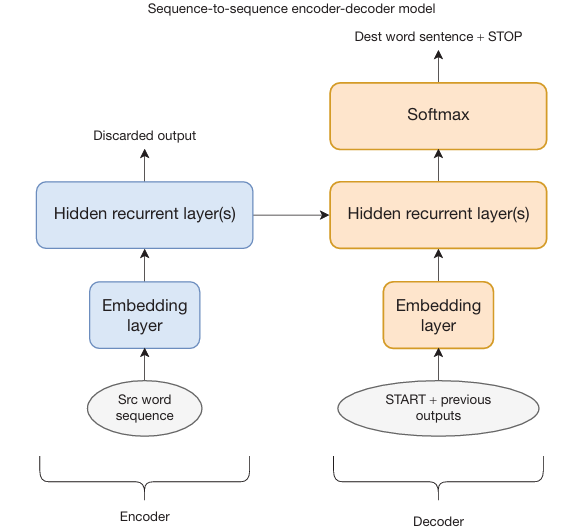 *Arquitetura encoder-decoder para tradução que será usada nesse material*

Com base na imagem acima, nota-se que as camadas da rede no codificador são distintas das camadas da rede no decodificador. A seta horizontal representa a leitura dos estados internos das camadas recorrentes no codificador e a inicialização dos estados internos das camadas recorrentes no decodificador. Assim, a suposição na figura é que ambas as redes contêm o mesmo número de camadas recorrentes ocultas do mesmo tamanho e tipo.

## **HANDS-ON: EXEMPLO DE PROGRAMAÇÃO**

### Imports necessários

In [1]:
import numpy as np
import random
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
import logging 
tf.get_logger().setLevel(logging.ERROR)

### Definição de constantes

Tamanho de vocabulário de 10.000 símbolos, dos quais quatro índices são reservados para preenchimento (*padding*), palavras fora do vocabulário (*UNK*), *token* de *START* e *token* de *STOP*. Como o *corpus* de treinamento é grande, o número de linhas que iremos usar no treinamento é 'READ_LINES' (60.000). Nossas camadas consistem em 256 unidades ('LAYER_SIZE'), e as camadas de *embedding* produzem 128 dimensões ('EMBEDDING_WIDTH'). Usamos 20% ('TEST_PERCENT') do dataset como conjunto de teste e selecionamos ainda 20 frases ('SAMPLE_SIZE') para inspecionar em detalhes durante o treinamento.

In [2]:
EPOCHS = 20
BATCH_SIZE = 128
MAX_WORDS = 10000
READ_LINES = 60000
LAYER_SIZE = 256
EMBEDDING_WIDTH = 128
TEST_PERCENT = 0.2
SAMPLE_SIZE = 20
OOV_WORD = 'UNK'
PAD_INDEX = 0
OOV_INDEX = 1
START_INDEX = MAX_WORDS - 2
STOP_INDEX = MAX_WORDS - 1
MAX_LENGTH = 60
SRC_DEST_FILE_NAME = r'C:\Users\João Pedro\Documents\LDL\data\anki\fra.txt'

### Função para ler o arquivo de entrada e processamento inicial

In [3]:
def read_file_combined(file_name, max_len):
    file = open(file_name, 'r', encoding='utf-8')
    src_word_sequences = []
    dest_word_sequences = []
    for i, line in enumerate(file):
        if i == READ_LINES:
            break
        pair = line.split('\t')
        word_sequence = text_to_word_sequence(pair[1])
        src_word_sequence = word_sequence[0:max_len]
        src_word_sequences.append(src_word_sequence)
        word_sequence = text_to_word_sequence(pair[0])
        dest_word_sequence = word_sequence[0:max_len]
        dest_word_sequences.append(dest_word_sequence)
    file.close()
    return src_word_sequences, dest_word_sequences

### Funções para transformar palavra em token e vice-versa

In [4]:
def tokenize(sequences):
    #Tirando 2 do MAX_WORDS devido aos tokens de <START> e <STOP>
    tokenizer = Tokenizer(num_words=MAX_WORDS-2, oov_token=OOV_WORD)
    tokenizer.fit_on_texts(sequences)
    token_sequences = tokenizer.texts_to_sequences(sequences)
    return tokenizer, token_sequences

def tokens_to_words(tokenizer, seq):
    word_seq = []
    for index in seq:
        if index == PAD_INDEX:
            word_seq.append('PAD')
        elif index == OOV_INDEX:
            word_seq.append(OOV_WORD)
        elif index == START_INDEX:
            word_seq.append('START')
        elif index == STOP_INDEX:
            word_seq.append('STOP')
        else:
            word_seq.append(tokenizer.sequences_to_texts([[index]])[0])
    print(word_seq)

### Ler e tokenizar o arquivo

In [5]:
src_seq, dest_seq = read_file_combined(SRC_DEST_FILE_NAME, MAX_LENGTH)
src_tokenizer, src_token_seq = tokenize(src_seq)
dest_tokenizer, dest_token_seq = tokenize(dest_seq)

Agora é a hora de organizar os dados em tensores que podem ser usados para o treinamento e teste. Na primeira imagem deste material, indicamos que precisávamos preencher o início da sequência de saída com tantos símbolos *PAD* quantas fossem as palavras na sequência de entrada, mas isso foi quando imaginamos uma única rede neural. Agora que dividimos a rede em um *encoder* e um *decoder*, isso não é mais necessário, pois simplesmente não alimentaremos nada no *decoder* até que tenhamos passado a entrada completa pelo *encoder*. Abaixo, segue um exemplo em que 'src_input' é a entrada para a rede *encoder*, 'dest_input', para a rede *decoder* e 'dest_target' é saída desejada da rede *decoder*:

```bash
src_input = [PAD, PAD, PAD, id("je"), id("suis"), id("étudiant")]
dest_input = [START, id("i"), id("am"), id("a"), id("student"), STOP, PAD, PAD
dest_target = [one_hot_id("i"), one_hot_id("am"), one_hot_id("a"), one_hot_id("student"), one_hot_id(STOP), one_hot_id(PAD), one_hot_id(PAD), one_hot_id(PAD)]
```

No exemplo, *id(string)* refere-se ao índice tokenizado da *string*, e *one_hot_id* é a versão codificada em *one-hot* do índice. Assumimos que a frase de origem mais longa tem seis palavras, então preenchemos *src_input* para ter esse comprimento. Da mesma forma, assumimos que a frase de destino mais longa tem oito palavras, incluindo os *tokens* de *START* e *STOP*, então preenchemos tanto *dest_input* quanto *dest_target* para terem esse comprimento. Note como os símbolos em *dest_input* estão deslocados em uma posição em comparação com os símbolos em *dest_target*, porque quando fizermos a inferência mais tarde, as entradas na rede decodificadora virão da saída da rede para o passo de tempo anterior.

O preenchimento (*padding*) é feito para garantir que possamos usar mini-lotes para o treinamento. Ou seja, todas as frases de origem precisam ter o mesmo comprimento, e todas as frases de destino precisam ter o mesmo comprimento. Preenchemos a entrada de origem no início (pré-preenchimento) e a de destino no final (pós-preenchimento), o que não é óbvio. Afirmamos anteriormente que, ao usar o preenchimento, o modelo pode aprender a ignorar os valores preenchidos, mas também existe um mecanismo no *Keras* para mascarar os valores preenchidos.

### Convertendo as sequências tokenizadas para arrays numpy

In [6]:
dest_target_token_seq = [x + [STOP_INDEX] for x in dest_token_seq]
dest_input_token_seq = [[START_INDEX] + x for x in dest_target_token_seq]
src_input_data = pad_sequences(src_token_seq)
dest_input_data = pad_sequences(dest_input_token_seq, padding='post')
dest_target_data = pad_sequences(dest_target_token_seq, padding='post', maxlen=len(dest_input_data[0]))

### Dividindo manualmente o dataset em treino e teste

In [7]:
rows = len(src_input_data[:,0])
all_indices = list(range(rows))
test_rows = int(rows * TEST_PERCENT)
test_indices = random.sample(all_indices, test_rows)
train_indices = [x for x in all_indices if x not in test_indices]

train_src_input_data = src_input_data[train_indices]
train_dest_input_data = dest_input_data[train_indices]
train_dest_target_data = dest_target_data[train_indices]

test_src_input_data = src_input_data[test_indices]
test_dest_input_data = dest_input_data[test_indices]
test_dest_target_data = dest_target_data[test_indices]

#Criando uma amostra do conjunto de teste que será analisada melhor
test_indices = list(range(test_rows))
sample_indices = random.sample(test_indices, SAMPLE_SIZE)
sample_input_data = test_src_input_data[sample_indices]
sample_target_data = test_dest_target_data[sample_indices]

### Arquitetura e implementação do modelo encoder

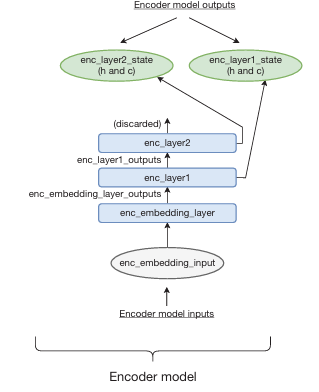 *Modelo econder*

Ele consiste em uma camada de *embedding* e duas camadas *LSTM*. As saídas desta imagem são as saídas de estado das duas camadas *LSTM* do *encoder*. Elas são usadas como entradas nas camadas *LSTM* do *decoder* para comunicar o estado acumulado do *encoder* para o *decoder*.

In [8]:
enc_embedding_input = Input(shape=(None, ))

#Camadas do encoder
enc_embedding_layer = Embedding(output_dim=EMBEDDING_WIDTH, input_dim=MAX_WORDS, mask_zero=True)
enc_layer1 = LSTM(LAYER_SIZE, return_state=True, return_sequences=True)
enc_layer2 = LSTM(LAYER_SIZE, return_state=True)

#Conectando as camadas do encoder
enc_embedding_layer_outputs = enc_embedding_layer(enc_embedding_input)
enc_layer1_outputs, enc_layer1_state_h, enc_layer1_state_c = enc_layer1(enc_embedding_layer_outputs)
_, enc_layer2_state_h, enc_layer2_state_c = enc_layer2(enc_layer1_outputs)

#Construindo o modelo
enc_model = Model(enc_embedding_input, [enc_layer1_state_h, enc_layer1_state_c, enc_layer2_state_h, enc_layer2_state_c])
enc_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 128) │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, None,     │    394,240 │ embedding[0][0],  │
│                     │ 256), (None,      │            │ not_equal[0][0]   │
│                     │ 256), (None,      │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 256),     │    525,312 │ lstm[0][0],       │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,199,552 (8.39 MB)

 Trainable params: 2,199,552 (8.39 MB)

 Non-trainable params: 0 (0.00 B)

### Arquitetura e implementação do modelo decoder

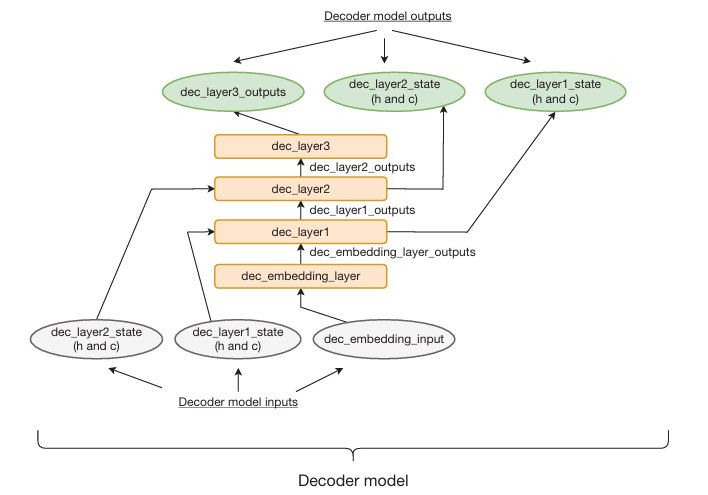 *Modelo decoder*

Ele consiste em uma camada de *embedding*, duas camadas *LSTM* e uma camada *softmax fully connected*. Além da frase no idioma de destino, ele recebe o estado de saída do modelo *encoder* como entradas.

In [9]:
dec_layer1_state_input_h = Input(shape=(LAYER_SIZE,))
dec_layer1_state_input_c = Input(shape=(LAYER_SIZE,))
dec_layer2_state_input_h = Input(shape=(LAYER_SIZE,))
dec_layer2_state_input_c = Input(shape=(LAYER_SIZE,))
dec_embedding_input = Input(shape=(None, ))

#Criando as camadas do decoder
dec_embedding_layer = Embedding(output_dim=EMBEDDING_WIDTH, input_dim=MAX_WORDS, mask_zero=True)
dec_layer1 = LSTM(LAYER_SIZE, return_state=True, return_sequences=True)
dec_layer2 = LSTM(LAYER_SIZE, return_state=True, return_sequences=True)
dec_layer3 = Dense(MAX_WORDS, activation='softmax')

#Conectando as camadas do decoder 
dec_embedding_layer_outputs = dec_embedding_layer(dec_embedding_input)
dec_layer1_outputs, dec_layer1_state_h, dec_layer1_state_c = dec_layer1(dec_embedding_layer_outputs, initial_state=[dec_layer1_state_input_h, dec_layer1_state_input_c])
dec_layer2_outputs, dec_layer2_state_h, dec_layer2_state_c = dec_layer2(dec_layer1_outputs, initial_state=[dec_layer2_state_input_h, dec_layer2_state_input_c])
dec_layer3_outputs = dec_layer3(dec_layer2_outputs)

#Construindo o modelo
dec_model = Model([dec_embedding_input, 
                   dec_layer1_state_input_h, 
                   dec_layer1_state_input_c, 
                   dec_layer2_state_input_h, 
                   dec_layer2_state_input_c], 
                   [dec_layer3_outputs, dec_layer1_state_h, 
                    dec_layer1_state_c, dec_layer2_state_h, 
                    dec_layer2_state_c])
dec_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 128) │  1,280,000 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, None,     │    394,240 │ embedding_1[0][0… │
│                     │ 256), (None,      │            │ input_layer_1[0]… │
│                     │ 256), (None,      │            │ input_layer_2[0]… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, None,     │    525,312 │ lstm_2[0][0],     │
│                     │ 256), (None,      │            │ input_layer_3[0]… │
│                     │ 256), (None,      │            │ input_layer_4[0]… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None,      │  2,570,000 │ lstm_3[0][0]      │
│                     │ 10000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,769,552 (18.19 MB)

 Trainable params: 4,769,552 (18.19 MB)

 Non-trainable params: 0 (0.00 B)

### Modelo encoder-decoder para treino

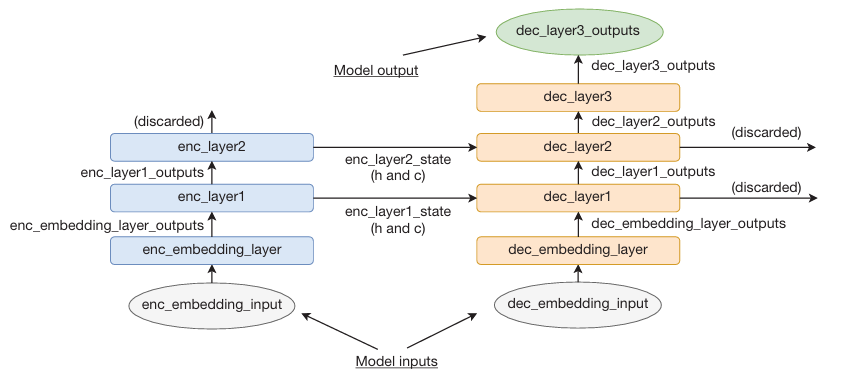 *Arquitetura completa do modelo*

Decidimos usar o *RMSProp* como otimizador, porque alguns experimentos indicam que ele tem um desempenho melhor do que o *Adam* para este modelo específico. Usamos *sparse_categorical_crossentropy* em vez da *categorical_crossentropy* normal como função de *loss*. Esta é a função de *loss* a ser usada no *Keras* se os dados de saída categóricos ainda não estiverem codificados em *one-hot*.

In [10]:
train_enc_embedding_input = Input(shape=(None, ))
train_dec_embedding_input = Input(shape=(None, ))
intermediate_state = enc_model(train_enc_embedding_input)
train_dec_output, _, _, _, _ = dec_model([train_dec_embedding_input] + intermediate_state)
training_model = Model([train_enc_embedding_input, train_dec_embedding_input], train_dec_output)
optimizer = RMSprop(learning_rate=0.01)
training_model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
training_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 256),     │  2,199,552 │ input_layer_6[0]… │
│ (Functional)        │ (None, 256),      │            │                   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ [(None, None,     │  4,769,552 │ input_layer_7[0]… │
│ (Functional)        │ 10000), (None,    │            │ functional[0][0], │
│                     │ 256), (None,      │            │ functional[0][1], │
│                     │ 256), (None,      │            │ functional[0][2], │
│                     │ 256), (None,      │            │ functional[0][3]  │
│                     │ 256)]             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,969,104 (26.59 MB)

 Trainable params: 6,969,104 (26.59 MB)

 Non-trainable params: 0 (0.00 B)

### Treinando e testando o modelo

Neste exemplo, criamos um laço próprio de treinamento, no qual instruímos o *fit()* a treinar por apenas uma única época de cada vez. Em seguida, usamos nosso modelo para criar algumas previsões antes de voltar e treinar por mais uma época. Esta abordagem permite uma avaliação detalhada de um pequeno conjunto de amostras após cada época

In [11]:
#Treinando e testando repetidamente
for i in range(EPOCHS):
    print('step: ', i)
    #Treinando o modelo por uma epoch
    history = training_model.fit([train_src_input_data, train_dest_input_data], train_dest_target_data, 
                                 validation_data=([test_src_input_data, test_dest_input_data], test_dest_target_data), 
                                 batch_size=BATCH_SIZE, epochs=1)
    
    #Loop pela amostra para ver o resultado
    for (test_input, test_target) in zip(sample_input_data, sample_target_data):
        #Executando um teste do modelo encoder
        x = np.reshape(test_input, (1, -1))
        last_states = enc_model.predict(x, verbose=0)
        #Input do decoder
        prev_word_index = START_INDEX
        produced_string = ''
        pred_seq = []
        for j in range(MAX_LENGTH):
            x = np.reshape(np.array(prev_word_index), (1, 1))
            #Predizer a próxima palavra e obter o estado interno
            preds, dec_layer1_state_h, dec_layer1_state_c, dec_layer2_state_h, dec_layer2_state_c = dec_model.predict([x] + last_states, verbose=0)
            last_states = [dec_layer1_state_h, 
                           dec_layer1_state_c, 
                           dec_layer2_state_h, 
                           dec_layer2_state_c]
            #Achando a palavra de maior probabilidade
            prev_word_index = np.asarray(preds[0][0]).argmax()
            pred_seq.append(prev_word_index)
            if prev_word_index == STOP_INDEX:
                break
        tokens_to_words(src_tokenizer, test_input)
        tokens_to_words(dest_tokenizer, test_target)
        tokens_to_words(dest_tokenizer, pred_seq)
        print('\n\n')

step:  0
375/375 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.2923 - loss: 4.4424 - val_accuracy: 0.3575 - val_loss: 2.5587
['PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'essayez', 'de', 'ne', 'pas', 'paniquer']
['try', 'not', 'to', 'panic', 'STOP', 'PAD', 'PAD', 'PAD', 'PAD']
['let', 'me', 'be', 'hard', 'STOP']



['PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'qui', 'a', 'mangé', 'avec', 'toi\xa0']
['who', 'ate', 'with', 'you', 'STOP', 'PAD', 'PAD', 'PAD', 'PAD']
['who', 'wants', 'the', 'key', 'STOP']



['PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'a', 't', 'il', 'peur', 'de', 'la', 'UNK']
['is', 'he', 'afraid', 'of', 'death', 'STOP', 'PAD', 'PAD', 'PAD']
['he', 'has', 'my', 'room', 'STOP']



['PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD', 'ce', 'sont', 'toutes', 'des', 'touristes']
["they're", 'all', 'tourists', 'STOP', 'PAD', 'PAD', 'PAD', 'PAD', 'PAD']
['they', 'are', 'you', 'STOP']



['PAD', 'PAD', 'PAD', 'PAD', 'PAD',

O *output* do treinamento acima ficou um pouco grande. Isso ocorreu devido a ideia de separar uma amostra dos dados para ver como estava o treinamento a cada iteração. Na última iteração, nota-se que os resultados desse teste nessa amostra foram muito bons. Com traduções iguais as esperadas e, em alguns casos, com palavras diferentes, porém, com o mesmo significado. Isso demonstra que a parte de **contexto** que o modelo *encoder* é responsável por extrair está ficando boa.